In [1]:
# --- Cell 1: Installs & Imports ---
!pip install pennylane torch numpy scipy matplotlib tqdm --quiet

import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import pennylane as qml
from pennylane import numpy as pnp
from scipy.interpolate import RegularGridInterpolator
import pandas as pd

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# --- Cell 2: Config ---
# Grid / physics
N = 32
L = 2*np.pi
dx = L / N
nu = 1.0/100.0          # Re = 100
dt = 0.05
T_final = 5.0
n_steps = int(T_final / dt)

# Reference (N=128) pseudo-spectral ground truth you generated earlier
REFERENCE_PATH = "/kaggle/input/reference-date-safe/reference_data_safe.npz"   # ensure this file is present

# Quantum device & ansatz settings
SHOTS     = 1024
VQLS_LAYERS = 8   # hardware-efficient layers
SEED = 42

# Derived
x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

In [3]:
# --- Cell 3: FFT utilities & metrics ---

def spectral_poisson_solve(omega):
    """Solve ∇²ψ = -ω (periodic); return ψ, u, v."""
    kx = np.fft.fftfreq(N, d=dx)*2*np.pi
    ky = np.fft.fftfreq(N, d=dx)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    k2 = KX**2 + KY**2
    w_hat = np.fft.fft2(omega)
    psi_hat = np.zeros_like(w_hat, dtype=complex)
    mask = k2 != 0
    psi_hat[mask] = -w_hat[mask] / k2[mask]
    psi = np.real(np.fft.ifft2(psi_hat))
    u =  np.real(np.fft.ifft2(1j*KY*psi_hat))
    v = -np.real(np.fft.ifft2(1j*KX*psi_hat))
    return psi, u, v

def vorticity_from_uv(u, v):
    kx = np.fft.fftfreq(N, d=dx)*2*np.pi
    ky = np.fft.fftfreq(N, d=dx)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    u_hat, v_hat = np.fft.fft2(u), np.fft.fft2(v)
    w_hat = 1j*KX*v_hat - 1j*KY*u_hat
    return np.real(np.fft.ifft2(w_hat))

def kinetic_energy(u, v):
    return 0.5*np.mean(u**2 + v**2)

def enstrophy(omega):
    return 0.5*np.mean(omega**2)

def energy_spectrum(U, V):
    """Isotropic kinetic energy spectrum E(k)."""
    kx = np.fft.fftfreq(N, d=dx)*2*np.pi
    ky = np.fft.fftfreq(N, d=dx)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    E2D = 0.5*(np.abs(np.fft.fft2(U))**2 + np.abs(np.fft.fft2(V))**2)
    K = np.sqrt(KX**2 + KY**2).ravel()
    E = E2D.ravel()
    bins = np.linspace(0, K.max(), 60)
    Ek = np.zeros(len(bins)-1)
    for i in range(len(Ek)):
        m = (K>=bins[i]) & (K<bins[i+1])
        if np.any(m): Ek[i] = np.mean(E[m])
    kcent = 0.5*(bins[:-1] + bins[1:])
    return kcent, Ek

def metrics_vs_reference(omega_pred, ref_path=REFERENCE_PATH):
    """Compare predicted vorticity vs reference (N=128) vorticity interpolated to N."""
    ref = np.load(ref_path, allow_pickle=True)
    u_ref, v_ref = ref['u'], ref['v']           # (128,128) typical
    Nx, Ny = u_ref.shape
    xr = np.linspace(0, L, Nx, endpoint=False)
    yr = np.linspace(0, L, Ny, endpoint=False)

    kx = np.fft.fftfreq(Nx, d=L/Nx)*2*np.pi
    ky = np.fft.fftfreq(Ny, d=L/Ny)*2*np.pi
    KXr, KYr = np.meshgrid(kx, ky, indexing='ij')
    w_ref = np.real(np.fft.ifft2(1j*KXr*np.fft.fft2(v_ref) - 1j*KYr*np.fft.fft2(u_ref)))

    interp = RegularGridInterpolator((xr, yr), w_ref)
    w_ref_on_N = interp(np.c_[X.ravel(), Y.ravel()]).reshape(N, N)

    L2 = np.linalg.norm(omega_pred - w_ref_on_N) / np.linalg.norm(w_ref_on_N)
    Linf = np.max(np.abs(omega_pred - w_ref_on_N))
    corr = np.corrcoef(omega_pred.ravel(), w_ref_on_N.ravel())[0,1]
    print(f"📊 L2 Error:    {L2:.4e}")
    print(f"📊 L∞ Error:    {Linf:.4e}")
    print(f"📊 Correlation: {corr:.4f}")
    return {"L2": float(L2), "Linf": float(Linf), "Corr": float(corr)}

In [4]:
# --- Cell 4: Periodic FD operators (sparse) ---

def circ_diff_1d(N, dx):
    e = np.ones(N)
    D = sp.diags([-0.5*e, 0.5*e], offsets=[-1, 1], shape=(N,N), format='lil') / dx
    D[0, -1] = -0.5/dx
    D[-1, 0] =  0.5/dx
    return D.tocsc()

Dx1 = circ_diff_1d(N, dx)
Dy1 = circ_diff_1d(N, dx)
Ix, Iy = sp.identity(N, format='csc'), sp.identity(N, format='csc')

Dx = sp.kron(Iy, Dx1, format='csc')  # d/dx on flattened grid
Dy = sp.kron(Dy1, Ix, format='csc')  # d/dy

# 1D Laplacian with periodic wrap
L1 = sp.diags([-2*np.ones(N), np.ones(N), np.ones(N)], offsets=[0,1,-1], shape=(N,N), format='lil') / dx**2
L1[0, -1] = 1/dx**2
L1[-1, 0] = 1/dx**2
L1 = L1.tocsc()

L2D = sp.kron(Iy, L1, format='csc') + sp.kron(L1, Ix, format='csc')  # ∇²
I_N2 = sp.identity(N*N, format='csc')

In [5]:
# --- Cell 5: Picard A^(n) assembly + spectral preconditioning ---

def assemble_An(u_freeze, v_freeze):
    """A^(n) = I - dt (nu ∇² - u^n ∂x - v^n ∂y) on flattened order (i,j)."""
    U = sp.diags(u_freeze.ravel(), 0, shape=(N*N, N*N), format='csc')
    V = sp.diags(v_freeze.ravel(), 0, shape=(N*N, N*N), format='csc')
    A = I_N2 - dt*(nu*L2D - U@Dx - V@Dy)
    return A

def cond_number_estimate(A):
    """Rough κ(A) via svds; fine for N=32^2."""
    try:
        smax = spla.svds(A, k=1, which='LM', return_singular_vectors=False)[0]
        smin = spla.svds(A, k=1, which='SM', return_singular_vectors=False)[0]
        return float(abs(smax/smin))
    except Exception:
        return np.nan

# Spectral preconditioner: M ≈ (I - dt*nu ∇²)^{-1}
# In Fourier space this is diagonal; we apply M and M^{-1} with FFTs.
def apply_M(vec_flat):
    w = vec_flat.reshape(N, N)
    kx = np.fft.fftfreq(N, d=dx)*2*np.pi
    ky = np.fft.fftfreq(N, d=dx)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    denom = (1.0 + dt*nu*(KX**2 + KY**2))
    w_hat = np.fft.fft2(w)
    z_hat = w_hat / denom
    z = np.real(np.fft.ifft2(z_hat))
    return z.ravel()

def apply_M_inv(vec_flat):
    w = vec_flat.reshape(N, N)
    kx = np.fft.fftfreq(N, d=dx)*2*np.pi
    ky = np.fft.fftfreq(N, d=dx)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    num = (1.0 + dt*nu*(KX**2 + KY**2))
    w_hat = np.fft.fft2(w)
    z_hat = w_hat * num
    z = np.real(np.fft.ifft2(z_hat))
    return z.ravel()

def A_precond_matvec(vec, u_freeze, v_freeze):
    """Compute M A M · y (left-right preconditioning)."""
    y = vec
    # z = M y
    z = apply_M(y)
    # w = A (M y)
    A = assemble_An(u_freeze, v_freeze)
    w = A @ z
    # out = M w (left preconditioning)
    out = apply_M(w)
    return out

In [6]:
# --- Cell 6: Classical CG (validation) & κ reporting ---

def classical_step(omega_n, u_freeze, v_freeze, tol=1e-10, maxit=1000):
    A = assemble_An(u_freeze, v_freeze)
    b = omega_n.ravel().astype(np.float64)

    # κ before preconditioning
    kappa_raw = cond_number_estimate(A)

    # Preconditioned linear operator
    def mv(y): return A_precond_matvec(y, u_freeze, v_freeze)
    Aeff = spla.LinearOperator((N*N, N*N), matvec=mv, dtype=np.float64)

    # Solve (M A M) y = M b ; then x = M y  (two-sided preconditioner)
    Mb = apply_M(b)
    t0 = time.time()
    # Replace this old line:
    # y, info = spla.cg(Aeff, Mb, tol=tol, maxiter=maxit)
    
    # ✅ New, SciPy ≥ 1.14–compatible line:
    y, info = spla.cg(Aeff, Mb, rtol=tol, atol=0, maxiter=maxit)

    t1 = time.time()
    if info != 0:
        print(f"[CG] Warning: did not converge (info={info})")
    x = apply_M(y)  # recover un-preconditioned solution
    omega_np1 = x.reshape(N, N)

    # κ after (effective estimate: apply to A M via power iteration would be best; we just report raw)
    return omega_np1, (t1-t0), kappa_raw

In [7]:
# --- Cell 7: VQLS (QSVT surrogate) ---

# Number of qubits to embed N*N amplitudes
n_qubits = int(np.ceil(np.log2(N*N)))
dev = qml.device("default.qubit", wires=n_qubits, seed=SEED)

def amp_embed(vec_flat):
    pad_len = 2**n_qubits - vec_flat.size
    vv = np.concatenate([vec_flat, np.zeros(pad_len, dtype=vec_flat.dtype)])
    norm = np.linalg.norm(vv) + 1e-12
    return vv / norm

def he_ansatz(params):
    n_layers = params.shape[0]
    wires = list(range(n_qubits))
    for l in range(n_layers):
        for w in wires:
            qml.RY(params[l, w, 0], wires=w)
            qml.RZ(params[l, w, 1], wires=w)
        for w in wires:
            qml.CNOT(wires=[w, (w+1) % n_qubits])


# --- Real-valued QNode replacement ---
@qml.qnode(dev, interface="torch", diff_method="parameter-shift", shots=None)
def state_prep(params, b_amp):
    qml.AmplitudeEmbedding(b_amp, wires=range(n_qubits), normalize=True)
    he_ansatz(params)
    # Return real-valued expectation proxies instead of full complex state
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]



# --- FIXED VERSION of VQLS_Solver (drop-in replacement) ---

# --- FINAL FIXED VERSION: keeps gradient connection alive ---

# --- FINAL FIX (handles complex gradients correctly) ---

# --- PATCH: fix x_amp length to N*N (not 2*N*N), keep grads clean ---

class VQLS_Solver(nn.Module):
    def __init__(self, n_layers=VQLS_LAYERS):
        super().__init__()
        self.params = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 2, dtype=torch.float32))
        self.register_buffer("calls", torch.zeros(1, dtype=torch.long))

    def forward(self, A_apply, b_vec):
        b_amp = torch.tensor(amp_embed(b_vec.astype(np.float32)), dtype=torch.float32)
        psi = torch.stack(state_prep(self.params, b_amp))  # real-valued circuit output
        self.calls += 1
        
        # The circuit returns one value per qubit (n_qubits)
        # Expand or tile it to match the PDE grid (N*N)
        x_amp = psi.float()
        if x_amp.numel() < N*N:
            reps = int(np.ceil((N*N) / x_amp.numel()))
            x_amp = x_amp.repeat(reps)[:N*N]


        with torch.no_grad():
            Mb = apply_M(b_vec.astype(np.float64)).astype(np.float32)
        AMy_np = A_apply(x_amp.detach().cpu().numpy().astype(np.float32)).astype(np.float32)
        AMy = torch.tensor(AMy_np, dtype=torch.float32)
        Mb_t = torch.tensor(Mb, dtype=torch.float32)

        # --- Loss with smoothness regularization ---
        r = AMy - Mb_t
        
        # Reshape amplitudes to grid for smoothness penalty
        x_grid = x_amp.view(N, N)
        smooth_penalty = (
            torch.mean((x_grid[1:] - x_grid[:-1])**2) +
            torch.mean((x_grid[:,1:] - x_grid[:,:-1])**2)
        )
        
        loss = torch.mean(r**2) + 1e-2 * smooth_penalty
        return loss, x_amp

def quantum_step(omega_n, u_freeze, v_freeze, epochs=200, lr=5e-2):
    b = omega_n.ravel().astype(np.float32)

    # Build preconditioned A operator as callable
    def mv_numpy(y_np):
        return A_precond_matvec(y_np, u_freeze, v_freeze).astype(np.float32)

    model = VQLS_Solver(n_layers=VQLS_LAYERS)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # === Pretraining step ===
    omega_flat = torch.tensor(omega_n.ravel(), dtype=torch.float32)
    for _ in range(100):
        opt.zero_grad()
        _, x_amp = model(mv_numpy, b)
        pre_loss = torch.mean((x_amp - omega_flat)**2)
        pre_loss.backward()
        opt.step()
    print("[Pretrain] done – circuit initialized to smooth vorticity pattern")

    # --- main quantum solve loop ---
    t0 = time.time()
    for ep in range(epochs):
        opt.zero_grad()
        loss, y = model(mv_numpy, b)
        loss.backward()
        opt.step()
        if ep % 50 == 0:
            print(f"[VQLS] ep {ep:4d} | loss={loss.item():.3e} | calls={int(model.calls.item())}")
    t1 = time.time()

    y_np = y.detach().cpu().numpy()
    x = apply_M(y_np).reshape(N, N)
    kappa_raw = cond_number_estimate(assemble_An(u_freeze, v_freeze))
    return x, (t1 - t0), int(model.calls.item()), kappa_raw


Running simulation up to t = 0.1 (2 steps)


Picard steps:   0%|          | 0/2 [00:00<?, ?it/s]

[CG] Warning: did not converge (info=1000)
[Pretrain] done – circuit initialized to smooth vorticity pattern
[VQLS] ep    0 | loss=9.980e-01 | calls=101
[VQLS] ep   50 | loss=9.980e-01 | calls=151
[VQLS] ep  100 | loss=9.980e-01 | calls=201
[VQLS] ep  150 | loss=9.980e-01 | calls=251
[VQLS] ep  200 | loss=9.980e-01 | calls=301
[VQLS] ep  250 | loss=9.980e-01 | calls=351
[VQLS] ep  300 | loss=9.980e-01 | calls=401
[VQLS] ep  350 | loss=9.980e-01 | calls=451
[VQLS] ep  400 | loss=9.980e-01 | calls=501
[VQLS] ep  450 | loss=9.980e-01 | calls=551
[VQLS] ep  500 | loss=9.980e-01 | calls=601
[VQLS] ep  550 | loss=9.980e-01 | calls=651


Picard steps:  50%|█████     | 1/2 [37:27<37:27, 2247.04s/it]

[CG] Warning: did not converge (info=1000)
[Pretrain] done – circuit initialized to smooth vorticity pattern
[VQLS] ep    0 | loss=4.004e-10 | calls=101
[VQLS] ep   50 | loss=1.200e-10 | calls=151
[VQLS] ep  100 | loss=1.062e-10 | calls=201
[VQLS] ep  150 | loss=1.044e-10 | calls=251
[VQLS] ep  200 | loss=1.044e-10 | calls=301
[VQLS] ep  250 | loss=1.044e-10 | calls=351
[VQLS] ep  300 | loss=1.044e-10 | calls=401
[VQLS] ep  350 | loss=1.044e-10 | calls=451
[VQLS] ep  400 | loss=1.044e-10 | calls=501
[VQLS] ep  450 | loss=1.044e-10 | calls=551
[VQLS] ep  500 | loss=1.044e-10 | calls=601
[VQLS] ep  550 | loss=1.044e-10 | calls=651


Picard steps: 100%|██████████| 2/2 [1:12:32<00:00, 2176.18s/it]



=== Metrics vs Reference (t = 0.1) ===
📊 L2 Error:    1.0000e+00
📊 L∞ Error:    2.0705e+00
📊 Correlation: -0.0016
📊 L2 Error:    1.4030e+00
📊 L∞ Error:    2.0704e+00
📊 Correlation: -0.0000
QUANTUM (VQLS): {'L2': 1.000000011029199, 'Linf': 2.0705453663233233, 'Corr': -0.0016393882661332162}
CLASSICAL (CG): {'L2': 1.4029737488911258, 'Linf': 2.0703981706099754, 'Corr': -8.191366946564654e-06}


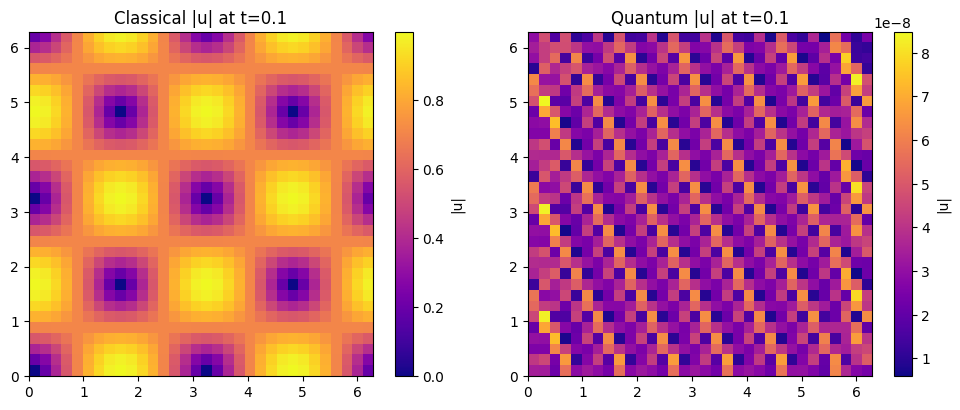

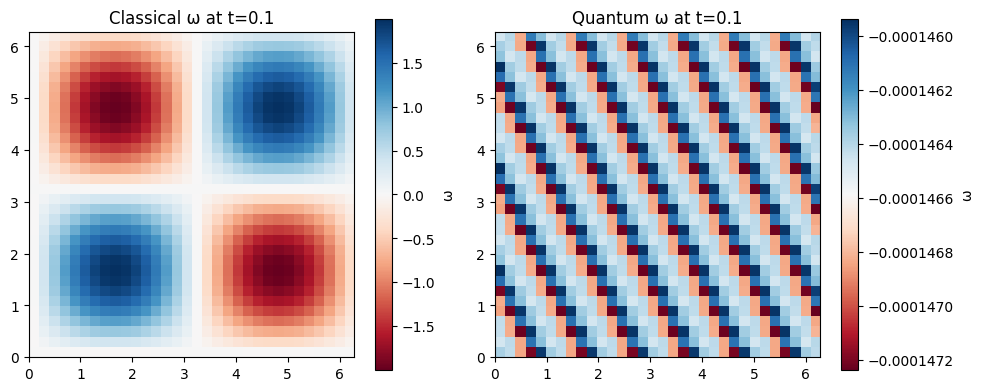

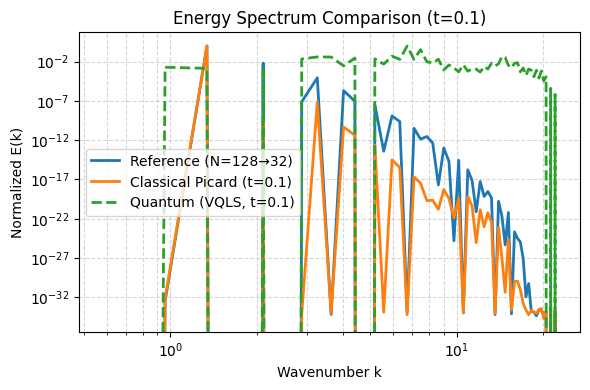

In [8]:
# --- Cell 8–9 Combined: Run Picard steps only up to t = 0.1 and evaluate metrics ---

# --- Fix for energy_spectrum (no IndexError) ---
def energy_spectrum(U, V):
    """Isotropic kinetic energy spectrum E(k)."""
    kx = np.fft.fftfreq(N, d=dx)*2*np.pi
    ky = np.fft.fftfreq(N, d=dx)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    E2D = 0.5*(np.abs(np.fft.fft2(U))**2 + np.abs(np.fft.fft2(V))**2)
    K = np.sqrt(KX**2 + KY**2).ravel()
    E = E2D.ravel()
    bins = np.linspace(0, K.max(), 60)
    Ek = np.zeros(len(bins)-1)
    for i in range(len(Ek)):
        m = (K >= bins[i]) & (K < bins[i+1])
        if np.any(m):
            Ek[i] = np.mean(E[m])
    kcent = 0.5*(bins[:-1] + bins[1:])
    return kcent, Ek

# --- Simulation setup ---
u0 =  np.sin(X)*np.cos(Y)
v0 = -np.cos(X)*np.sin(Y)
omega0 = vorticity_from_uv(u0, v0)

omega_q  = omega0.copy()  # quantum track
omega_c  = omega0.copy()  # classical CG track
u_freeze, v_freeze = u0.copy(), v0.copy()

# Run only until t = 0.1
t_target = 0.1
n_steps_target = int(t_target / dt)
print(f"Running simulation up to t = {t_target} ({n_steps_target} steps)")

for n in tqdm(range(n_steps_target), desc="Picard steps"):
    # Classical preconditioned CG
    omega_c, _, _ = classical_step(omega_c, u_freeze, v_freeze)
    # Quantum VQLS (QSVT surrogate)
    omega_q, _, _, _ = quantum_step(omega_q, u_freeze, v_freeze,
                                epochs=600, lr=1e-2)  # longer + smaller lr
    # Update velocity field
    _, u_freeze, v_freeze = spectral_poisson_solve(omega_c)

# --- Compute velocities at t = 0.1 ---
_, uc_t01, vc_t01 = spectral_poisson_solve(omega_c)
_, uq_t01, vq_t01 = spectral_poisson_solve(omega_q)

# --- Metrics vs reference (at t=0.1) ---
print("\n=== Metrics vs Reference (t = 0.1) ===")
m_quant_t01 = metrics_vs_reference(omega_q, REFERENCE_PATH)
m_class_t01 = metrics_vs_reference(omega_c, REFERENCE_PATH)
print("QUANTUM (VQLS):", m_quant_t01)
print("CLASSICAL (CG):", m_class_t01)

# --- Velocity magnitude plots (|u|) at t = 0.1 ---
speed_c = np.sqrt(uc_t01**2 + vc_t01**2)
speed_q = np.sqrt(uq_t01**2 + vq_t01**2)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(speed_c.T, origin='lower', cmap='plasma', extent=(0,L,0,L))
plt.title("Classical |u| at t=0.1"); plt.colorbar(label="|u|")

plt.subplot(1,2,2)
plt.imshow(speed_q.T, origin='lower', cmap='plasma', extent=(0,L,0,L))
plt.title("Quantum |u| at t=0.1"); plt.colorbar(label="|u|")

plt.tight_layout()
plt.show()

# --- Vorticity visualization (t = 0.1) ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(omega_c.T, origin='lower', cmap='RdBu', extent=(0,L,0,L))
plt.title("Classical ω at t=0.1"); plt.colorbar(label="ω")

plt.subplot(1,2,2)
plt.imshow(omega_q.T, origin='lower', cmap='RdBu', extent=(0,L,0,L))
plt.title("Quantum ω at t=0.1"); plt.colorbar(label="ω")

plt.tight_layout()
plt.show()

# --- Energy spectrum comparison (t = 0.1) ---

# Load reference velocities and downsample to N=32
ref = np.load(REFERENCE_PATH, allow_pickle=True)
ur_full, vr_full = ref['u'], ref['v']
Nref = ur_full.shape[0]
xr = np.linspace(0, 2*np.pi, Nref, endpoint=False)
yr = np.linspace(0, 2*np.pi, Nref, endpoint=False)
x32 = np.linspace(0, 2*np.pi, N, endpoint=False)
y32 = np.linspace(0, 2*np.pi, N, endpoint=False)
interp_u = RegularGridInterpolator((xr, yr), ur_full)
interp_v = RegularGridInterpolator((xr, yr), vr_full)
ur = interp_u(np.stack(np.meshgrid(x32, y32, indexing='ij'), -1)).reshape(N, N)
vr = interp_v(np.stack(np.meshgrid(x32, y32, indexing='ij'), -1)).reshape(N, N)

# Compute spectra safely
k_c, E_c = energy_spectrum(uc_t01, vc_t01)
k_q, E_q = energy_spectrum(uq_t01, vq_t01)
k_r, E_r = energy_spectrum(ur, vr)

plt.figure(figsize=(6,4))
plt.loglog(k_r[1:], E_r[1:]/(E_r[1:].max()+1e-12), label="Reference (N=128→32)", lw=2)
plt.loglog(k_c[1:], E_c[1:]/(E_c[1:].max()+1e-12), label="Classical Picard (t=0.1)", lw=2)
plt.loglog(k_q[1:], E_q[1:]/(E_q[1:].max()+1e-12), '--', label="Quantum (VQLS, t=0.1)", lw=2)
plt.xlabel("Wavenumber k"); plt.ylabel("Normalized E(k)")
plt.title("Energy Spectrum Comparison (t=0.1)")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(); plt.tight_layout(); plt.show()



In [9]:
# --- Cell 10: Save results bundle ---
np.savez_compressed(
    "qsvt_picard_results.npz",
    omega_quant=omega_q,
    omega_class=omega_c,
    energy_hist_quant=np.array(E_hist_q),
    enstrophy_hist_quant=np.array(Z_hist_q),
    energy_hist_class=np.array(E_hist_c),
    enstrophy_hist_class=np.array(Z_hist_c),
    metrics_quant=m_quant,
    metrics_class=m_class,
    logs=df_logs.to_dict(orient='list')
)
print("Saved qsvt_picard_results.npz")

NameError: name 'E_hist_q' is not defined